# Model Visualization
Visual evaluation of the trained Random Forest classifier.

## Setup — Load Data & Train Model

In [1]:
from src.data import load_raw, preprocess
from src.models import train_model_random_forest

df = load_raw()
df = preprocess(df)
model, X_train, X_test, y_train, y_test = train_model_random_forest(df=df, save=False)
y_pred = model.predict(X_test)

## 1 · Classification Report

In [2]:
from sklearn.metrics import classification_report, accuracy_score

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")
print(classification_report(y_test, y_pred, target_names=["Did not survive", "Survived"]))

Accuracy: 80.61%

                 precision    recall  f1-score   support

Did not survive       0.78      0.97      0.86       168
       Survived       0.91      0.52      0.66        95

       accuracy                           0.81       263
      macro avg       0.84      0.74      0.76       263
   weighted avg       0.83      0.81      0.79       263



## 2 · Confusion Matrix

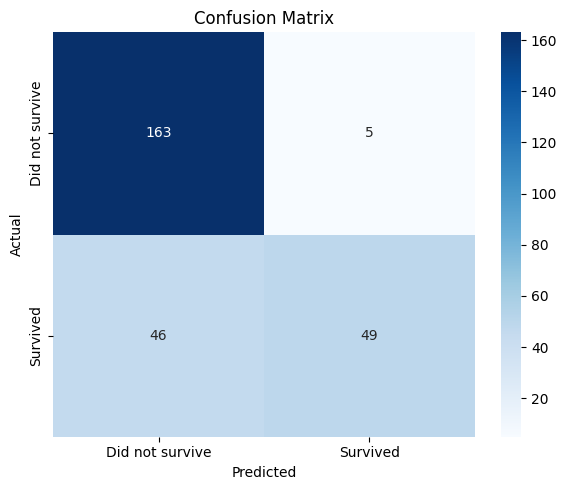

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Did not survive", "Survived"],
    yticklabels=["Did not survive", "Survived"],
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

## 3 · Feature Importance

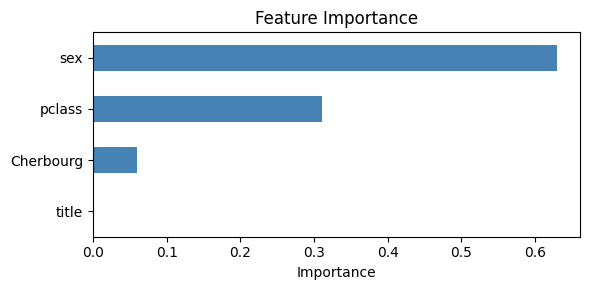

In [4]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(6, 3))
importance.plot.barh(color="steelblue", ax=ax)
ax.set_title("Feature Importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()